In [142]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sohaibdevv/ai-and-student-life-2026-the-new-normal/AI_Impact_Student_Life_2026.csv


In [143]:
df=pd.read_csv('/kaggle/input/datasets/sohaibdevv/ai-and-student-life-2026-the-new-normal/AI_Impact_Student_Life_2026.csv')


In [144]:
df.columns

Index(['Student_ID', 'Age', 'Major', 'Primary_AI_Tool', 'Task_Frequency_Daily',
       'Main_Usage_Case', 'GPA_Baseline', 'GPA_Post_AI',
       'Time_Saved_Hours_Weekly', 'AI_Ethics_Concern',
       'Career_Confidence_Score'],
      dtype='object')

In [145]:
df=df.set_index('Student_ID')

In [146]:
df.head()

,Age,Major,Primary_AI_Tool,Task_Frequency_Daily,Main_Usage_Case,GPA_Baseline,GPA_Post_AI,Time_Saved_Hours_Weekly,AI_Ethics_Concern,Career_Confidence_Score
Student_ID,,,,,,,,,,
STU-6019,23,Software Engineering,Gemini Pro,1,Code Debugging,2.62,2.62,9,Medium,3
STU-6962,22,Modern History,GitHub Copilot,3,Essay Drafting,3.99,4.00,7,Medium,4
STU-2338,18,Data Science,Perplexity,2,Literature Review,2.57,2.57,15,High,7
STU-1380,19,Biology,Claude 3.5,5,Essay Drafting,2.67,2.87,12,Low,5
STU-1837,19,Biology,ChatGPT-4o,10,Code Debugging,3.65,3.85,5,High,9


In [147]:
print(df['GPA_Baseline'].mean())
print(df['GPA_Post_AI'].mean())

3.256853333333334
3.344586666666667


In [148]:
print((df['GPA_Post_AI'].mean() - df['GPA_Baseline'].mean())*100)

8.7733333333333


In [149]:
df_GPA_IA=df.groupby('Major')[['GPA_Baseline','GPA_Post_AI']].mean().sort_values(by=['GPA_Baseline','GPA_Post_AI'])
df_GPA_IA

,GPA_Baseline,GPA_Post_AI
Major,,
Software Engineering,3.229917,3.332314
Fine Arts,3.230380,3.305513
Business Administration,3.237891,3.328789
Data Science,3.245985,3.329923
Modern History,3.293213,3.374253
Biology,3.307490,3.400695


In [150]:
df_GPA_IA["cambio_pct"] = (
    (df_GPA_IA["GPA_Post_AI"] - df_GPA_IA["GPA_Baseline"]) 
    / df_GPA_IA["GPA_Baseline"]
) * 100


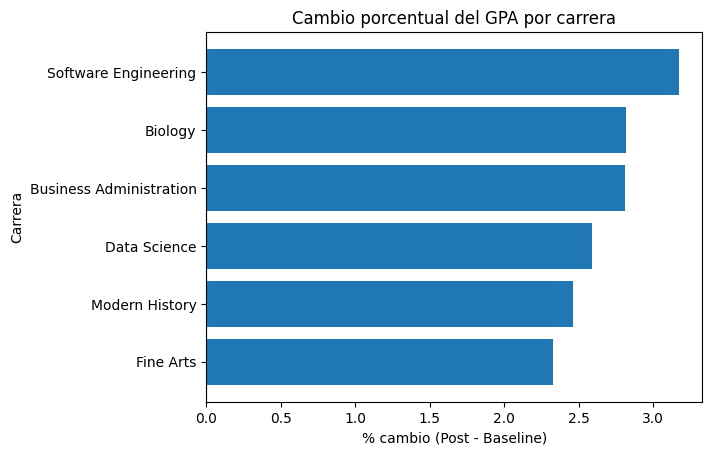

In [151]:
df_sorted = df_GPA_IA.sort_values("cambio_pct")

plt.barh(df_sorted.index, df_sorted["cambio_pct"])
plt.axvline(0)

plt.title("Cambio porcentual del GPA por carrera")
plt.xlabel("% cambio (Post - Baseline)")
plt.ylabel("Carrera")

plt.show()

In [152]:

df_GPA_IA['cambio_pct'].sort_values(ascending=False)

Major
Software Engineering       3.170257
Biology                    2.817987
Business Administration    2.807335
Data Science               2.585910
Modern History             2.460841
Fine Arts                  2.325828
Name: cambio_pct, dtype: float64

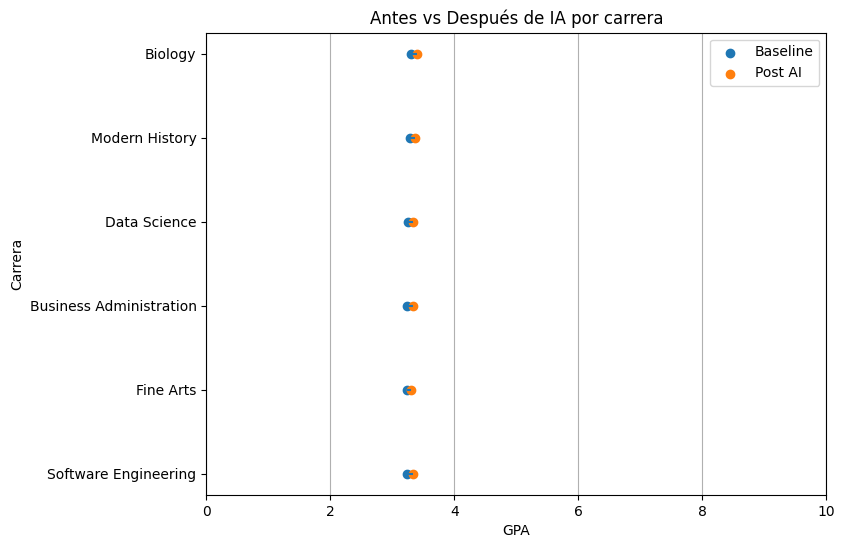

In [153]:
df_sorted = df_GPA_IA.sort_values("GPA_Baseline")

plt.figure(figsize=(8,6))

# línea horizontal entre puntos
plt.hlines(
    y=df_sorted.index,
    xmin=df_sorted["GPA_Baseline"],
    xmax=df_sorted["GPA_Post_AI"]
)

# puntos
plt.scatter(df_sorted["GPA_Baseline"], df_sorted.index, label="Baseline")
plt.scatter(df_sorted["GPA_Post_AI"], df_sorted.index, label="Post AI")

plt.xlabel("GPA")
plt.ylabel("Carrera")
plt.title("Antes vs Después de IA por carrera")

plt.xlim(0, 10)
plt.legend()
plt.grid(axis='x')

plt.show()

In [154]:
df.groupby('Primary_AI_Tool')['Task_Frequency_Daily'].mean().sort_values(ascending=False)


Primary_AI_Tool
GitHub Copilot    5.652733
Perplexity        5.456954
ChatGPT-4o        5.402778
Claude 3.5        5.323232
Gemini Pro        5.192053
Name: Task_Frequency_Daily, dtype: float64

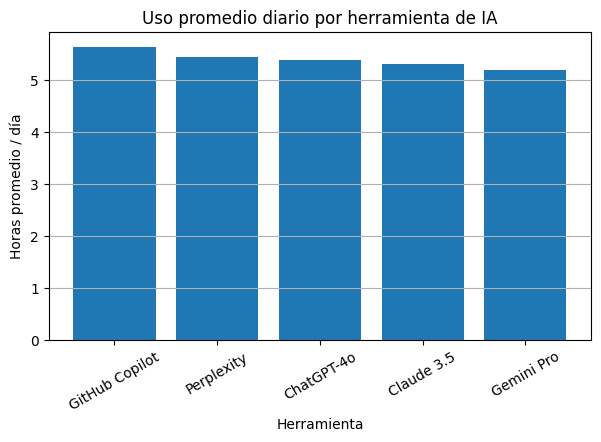

In [155]:

plt.figure(figsize=(7,4))
plt.bar(promedio.index, promedio.values)

plt.title("Uso promedio diario por herramienta de IA")
plt.xlabel("Herramienta")
plt.ylabel("Horas promedio / día")

plt.xticks(rotation=30)
plt.grid(axis='y')

plt.show()

In [156]:
top_ai = (
    df.groupby('Major')['Primary_AI_Tool']
      .agg(lambda x: x.value_counts().idxmax())
)

top_ai

Major
Biology                        Gemini Pro
Business Administration        Perplexity
Data Science                   Gemini Pro
Fine Arts                  GitHub Copilot
Modern History                 ChatGPT-4o
Software Engineering           Gemini Pro
Name: Primary_AI_Tool, dtype: object

In [157]:
mapa = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

df['AI_Ethics_Concern_num'] = df['AI_Ethics_Concern'].map(mapa)

In [158]:
df.groupby('Major')['AI_Ethics_Concern_num'].mean()

Major
Biology                    1.938224
Business Administration    1.937500
Data Science               1.996139
Fine Arts                  2.034221
Modern History             1.981900
Software Engineering       2.004132
Name: AI_Ethics_Concern_num, dtype: float64

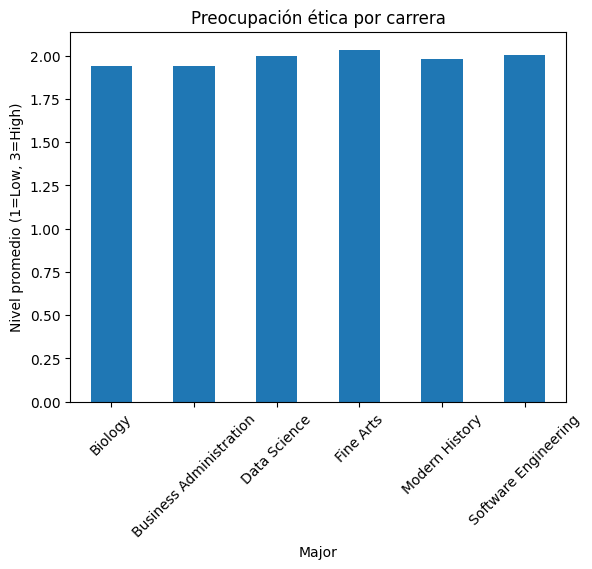

In [159]:


df.groupby('Major')['AI_Ethics_Concern_num'].mean().plot(kind='bar')

plt.title("Preocupación ética por carrera")
plt.ylabel("Nivel promedio (1=Low, 3=High)")
plt.xticks(rotation=45)

plt.show()

In [160]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


X = df[['Task_Frequency_Daily']].copy()
y = df['Career_Confidence_Score'].copy()


X = X.dropna()
y = y.loc[X.index]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print("Coef:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Coef: 0.02918168341101087
Intercept: 5.267692927315164
R2: -0.0006882006852861888
MAE: 2.471586926971341


In [161]:
X = df[['Task_Frequency_Daily', 'AI_Ethics_Concern_num']]

Text(0.5, 1.0, 'Uso de IA vs Confianza (con jitter)')

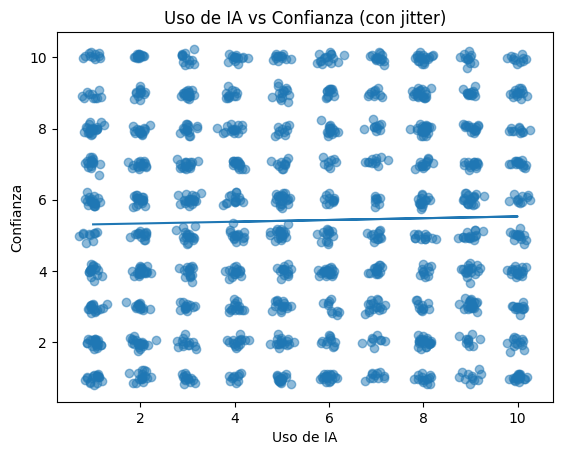

In [162]:

X = df['Task_Frequency_Daily']
y = df['Career_Confidence_Score']

# jitter
x_jitter = X + np.random.normal(0, 0.1, size=len(X))
y_jitter = y + np.random.normal(0, 0.1, size=len(y))

plt.scatter(x_jitter, y_jitter, alpha=0.5)

# línea de regresión
coef = np.polyfit(X, y, 1)
linea = np.poly1d(coef)
plt.plot(X, linea(X))

plt.xlabel("Uso de IA")
plt.ylabel("Confianza")
plt.title("Uso de IA vs Confianza (con jitter)")

In [163]:
pd.crosstab(df['Major'], df['Primary_AI_Tool'], normalize='index')

Primary_AI_Tool,ChatGPT-4o,Claude 3.5,Gemini Pro,GitHub Copilot,Perplexity
Major,,,,,
Biology,0.208494,0.173745,0.223938,0.193050,0.200772
Business Administration,0.183594,0.222656,0.136719,0.214844,0.242188
Data Science,0.166023,0.200772,0.243243,0.204633,0.185328
Fine Arts,0.178707,0.224335,0.167300,0.235741,0.193916
Modern History,0.239819,0.185520,0.226244,0.176471,0.171946
Software Engineering,0.181818,0.177686,0.214876,0.214876,0.210744


In [164]:
from sklearn.linear_model import LinearRegression

X = df[['Task_Frequency_Daily']].copy()
y = df['GPA_Post_AI'].copy()

X = X.dropna()
y = y.loc[X.index]

model_gpa = LinearRegression()
model_gpa.fit(X, y)

print("Coef impacto IA->GPA:", model_gpa.coef_[0])

Coef impacto IA->GPA: 0.0006802169665014047
